In [1]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\user121\anaconda3\New folder\python.exe
3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]


In [2]:
from wordcloud import WordCloud
print("WordCloud is working!")


WordCloud is working!


In [3]:

# Import necessary libraries

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from PIL import Image, ImageDraw
  

In [4]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user121\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user121\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user121\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
 # Music Preferences Dataset

text = """
bollywood bollywood bollywood bollywood bollywood
bollywood bollywood bollywood bollywood
pop pop pop pop pop pop pop pop
pop pop pop pop
rock rock rock rock rock rock rock
rock rock rock
classical classical classical classical classical
classical classical classical
lofi lofi lofi lofi lofi lofi lofi
lofi lofi lofi
jazz jazz jazz jazz jazz jazz
jazz jazz
hiphop hiphop hiphop hiphop hiphop
hiphop hiphop hiphop
indie indie indie indie indie
indie indie
punjabi punjabi punjabi punjabi punjabi
punjabi punjabi
kpop kpop kpop kpop
kpop kpop
rap rap rap rap rap
rap rap
folk folk folk folk
folk folk
country country country
country
reggae reggae reggae
reggae reggae
electronic electronic electronic electronic
electronic electronic
metal metal metal
metal metal
soul soul soul soul
soul soul
blues blues blues
blues blues
"""

print(text)



bollywood bollywood bollywood bollywood bollywood
bollywood bollywood bollywood bollywood
pop pop pop pop pop pop pop pop
pop pop pop pop
rock rock rock rock rock rock rock
rock rock rock
classical classical classical classical classical
classical classical classical
lofi lofi lofi lofi lofi lofi lofi
lofi lofi lofi
jazz jazz jazz jazz jazz jazz
jazz jazz
hiphop hiphop hiphop hiphop hiphop
hiphop hiphop hiphop
indie indie indie indie indie
indie indie
punjabi punjabi punjabi punjabi punjabi
punjabi punjabi
kpop kpop kpop kpop
kpop kpop
rap rap rap rap rap
rap rap
folk folk folk folk
folk folk
country country country
country
reggae reggae reggae
reggae reggae
electronic electronic electronic electronic
electronic electronic
metal metal metal
metal metal
soul soul soul soul
soul soul
blues blues blues
blues blues



In [6]:
# Convert text into individual words

words = word_tokenize(text.lower())

print("Total words:", len(words))
print(words[:50])

# Remove common English stopwords

stop_words = set(stopwords.words('english'))

filtered_words = [
    word for word in words
    if word.isalpha() and word not in stop_words
]

print("\nFiltered words:")
print(filtered_words[:50])

Total words: 129
['bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'classical', 'classical', 'classical', 'classical', 'classical', 'classical', 'classical', 'classical', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'jazz']

Filtered words:
['bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'bollywood', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'rock', 'classical', 'classical', 'classical', 'classical', 'classical', 'classical', 'classical', 'classical', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'lofi', 'jazz']


In [7]:
# Count the frequency of each music genre

word_freq = Counter(filtered_words)

print("Music Genre Frequencies:\n")

for genre, frequency in word_freq.most_common():
    print(f"{genre}: {frequency}")

Music Genre Frequencies:

pop: 12
rock: 10
lofi: 10
bollywood: 9
classical: 8
jazz: 8
hiphop: 8
indie: 7
punjabi: 7
rap: 7
kpop: 6
folk: 6
electronic: 6
soul: 6
reggae: 5
metal: 5
blues: 5
country: 4


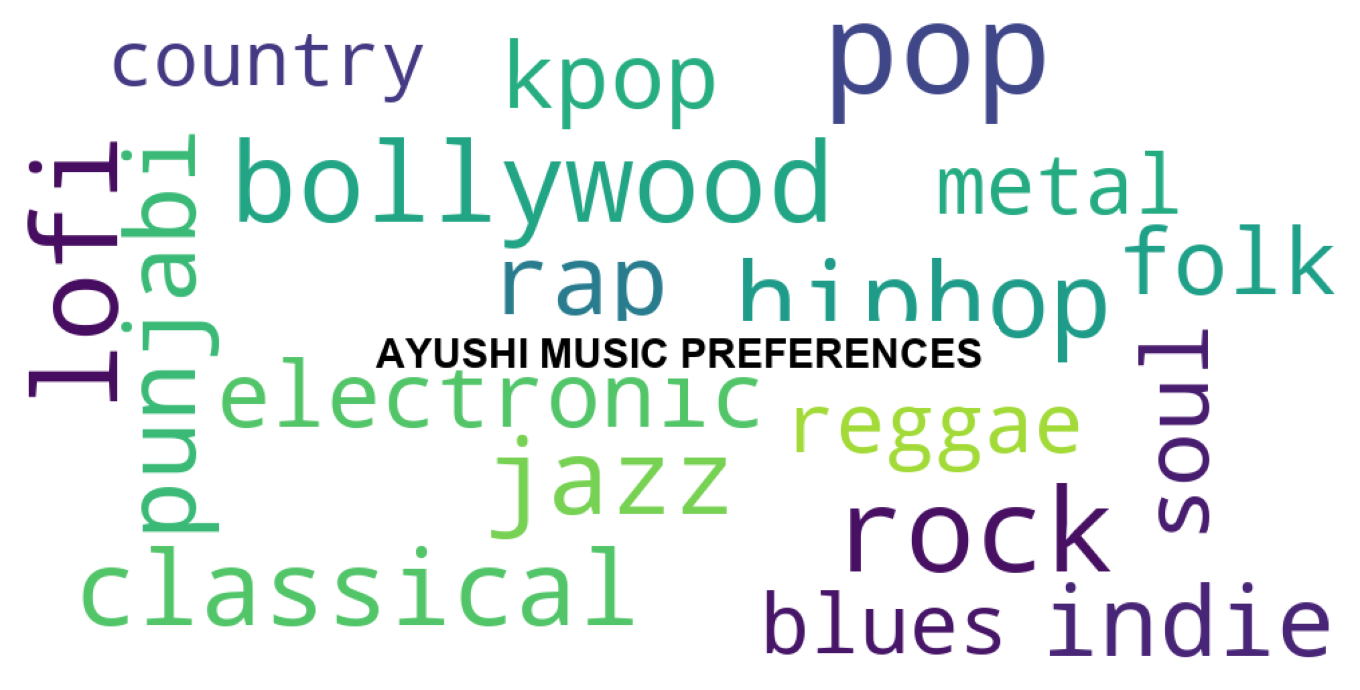

In [10]:
# Create a full and dense Word Cloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis",
    max_words=80,
    min_font_size=8,
    max_font_size=95,
    margin=3,
    prefer_horizontal=0.9,
    relative_scaling=0.5,
    collocations=False,
    random_state=25
).generate_from_frequencies(word_freq)


# Convert WordCloud to image
wc_image = wordcloud.to_image().convert("RGB")


# Add personalized heading
from PIL import ImageDraw, ImageFont

draw = ImageDraw.Draw(wc_image)

font_path = "C:/Windows/Fonts/arialbd.ttf"

try:
    heading_font = ImageFont.truetype(font_path, 30)
except:
    heading_font = ImageFont.load_default()


heading = "AYUSHI MUSIC PREFERENCES"


# Find heading dimensions
bbox = draw.textbbox((0, 0), heading, font=heading_font)

text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]

x = (1000 - text_width) // 2
y = (500 - text_height) // 2


# Small white box behind the heading
draw.rounded_rectangle(
    (
        x - 12,
        y - 7,
        x + text_width + 12,
        y + text_height + 7
    ),
    radius=8,
    fill="white"
)


# Write heading
draw.text(
    (x, y),
    heading,
    fill="black",
    font=heading_font
)


# Display final Word Cloud
plt.figure(figsize=(15, 7))
plt.imshow(wc_image)
plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
# Save the final Word Cloud as JPG

wc_image.save(
    "Ayushi_Music_WordCloud.jpg",
    quality=95
)

print("JPG saved successfully!")
print("File name: Ayushi_Music_WordCloud.jpg")

JPG saved successfully!
File name: Ayushi_Music_WordCloud.jpg


In [12]:
import os
print(os.getcwd())

C:\Users\user121
